# 05 — Frozen unseen-outlet evaluation and error analysis

Only now do we open `test_ood`. We first recover the selected n-gram configuration, refit it
on all non-holdout development data, and evaluate once on the five held-out publications.
The resulting scores measure **publication-proxy generalization**, not independently judged
headline bias.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

DATA_PATH = ROOT / "data/processed/publication_proxy_headlines.csv"

In [2]:
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

from bias_dataset.modeling import (
    LABEL_ORDER, ORDINAL_VALUE, attach_split, build_word_logistic,
    load_modeling_data, per_class_report, prediction_metrics,
)

sns.set_theme(style="whitegrid")

In [3]:
SPLIT_PATH = ROOT / "data/splits/pilot_v1.csv"
DEVELOPMENT_MODEL_PATH = ROOT / "models/selected_development_lr.joblib"
FINAL_MODEL_PATH = ROOT / "models/pilot_final_lr.joblib"
REPORT_DIR = ROOT / "reports/modeling"

## Reconfirm the frozen data roles

In [4]:
data = load_modeling_data(DATA_PATH)
manifest = pd.read_csv(SPLIT_PATH)
modeled = attach_split(data, manifest)

development = modeled[modeled["split"].isin(["train", "validation"])].copy()
test_ood = modeled[modeled["split"].eq("test_ood")].copy()
print({"development": len(development), "test_ood": len(test_ood)})

{'development': 537, 'test_ood': 496}


In [5]:
development_sources = set(development["source_id"])
test_sources = set(test_ood["source_id"])
assert development_sources.isdisjoint(test_sources)
assert set(development["headline_hash"]).isdisjoint(test_ood["headline_hash"])
print("PASS: no outlet or exact-headline overlap with OOD test.")

PASS: no outlet or exact-headline overlap with OOD test.


## Refit the selected architecture on all development rows

In [6]:
development_model = joblib.load(DEVELOPMENT_MODEL_PATH)
selected_ngram_range = development_model.named_steps["tfidf"].ngram_range
print("Selected n-gram range:", selected_ngram_range)

Selected n-gram range: (1, 1)


In [7]:
final_model = build_word_logistic(ngram_range=selected_ngram_range, min_df=2)
final_model.fit(development["model_text"], development["weak_label"])
joblib.dump(final_model, FINAL_MODEL_PATH)
print("Final vocabulary size:", len(final_model.named_steps["tfidf"].get_feature_names_out()))

Final vocabulary size: 826


## Make the one-time OOD predictions

In [8]:
prediction = final_model.predict(test_ood["model_text"])
probability = final_model.predict_proba(test_ood["model_text"])
metrics = prediction_metrics(test_ood["weak_label"], prediction)
pd.Series(metrics, name="unseen_outlet_test").round(3)

accuracy                     0.220
macro_precision              0.217
macro_recall                 0.252
macro_f1                     0.197
weighted_f1                  0.232
ordinal_mae                  1.510
within_one_class_accuracy    0.548
quadratic_weighted_kappa     0.126
Name: unseen_outlet_test, dtype: float64

Macro-F1 is primary because every ideological class counts equally. Ordinal MAE measures how
many class steps an error travels, while within-one-class accuracy credits adjacent mistakes.
Quadratic kappa penalizes distant ideological errors more strongly.

## Inspect per-class precision and recall

In [9]:
class_report = per_class_report(test_ood["weak_label"], prediction)
class_report.round(3)

,precision,recall,f1-score,support
Left,0.509,0.386,0.439,153.0
Lean Left,0.114,0.295,0.165,44.0
Center,0.056,0.261,0.092,23.0
Lean Right,0.288,0.091,0.138,232.0
Right,0.116,0.227,0.154,44.0


## Raw and normalized confusion matrices

In [10]:
raw_matrix = confusion_matrix(test_ood["weak_label"], prediction, labels=LABEL_ORDER)
normalized_matrix = confusion_matrix(
    test_ood["weak_label"], prediction, labels=LABEL_ORDER, normalize="true"
)

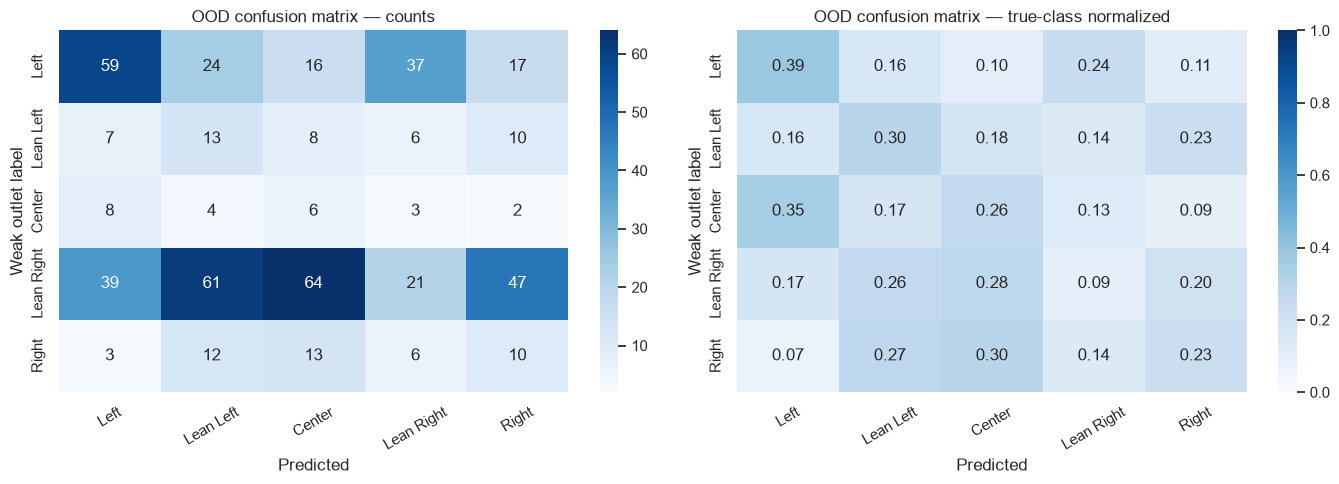

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(raw_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER)
sns.heatmap(normalized_matrix, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, vmin=0, vmax=1)
axes[0].set_title("OOD confusion matrix — counts")
axes[1].set_title("OOD confusion matrix — true-class normalized")
for axis in axes:
    axis.set(xlabel="Predicted", ylabel="Weak outlet label")
    axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Build a row-level error table

In [12]:
results = test_ood[["record_id", "source_id", "headline", "weak_label"]].copy()
results["prediction"] = prediction
results["confidence"] = probability.max(axis=1)
results["correct"] = results["weak_label"].eq(results["prediction"])
results["ordinal_distance"] = [
    abs(ORDINAL_VALUE[truth] - ORDINAL_VALUE[pred])
    for truth, pred in zip(results["weak_label"], results["prediction"])
]
results.head()

,record_id,source_id,headline,weak_label,prediction,confidence,correct,ordinal_distance
0,4635aacf62952a624ca2a8564201e8355ea0cb01f1d83d...,cnn,The 2024 presidential alternative many voters ...,Lean Left,Left,0.231456,False,1
1,54d03d8e006392742494cc2f473ce2bd2340b749fcb442...,cnn,Russia is 'going backwards' in equipment and d...,Lean Left,Lean Left,0.306757,True,0
2,5561eb4d0084c49afa57b87c37a157493e930e3866f082...,cnn,Dominion still has pending lawsuits against el...,Lean Left,Right,0.250746,False,3
3,e6f7461b12cc8b342fc85e0578b28f315e68a5f74ad80d...,cnn,CNN Political Briefing,Lean Left,Lean Left,0.270526,True,0
4,f1ef285a4c60a5b59bd5e1eacbc74828e5ea92a79e742d...,cnn,The Axe Files with David Axelrod,Lean Left,Left,0.397356,False,1


## Review the most confident errors

In [13]:
columns = ["source_id", "headline", "weak_label", "prediction", "confidence", "ordinal_distance"]
confident_errors = results[~results["correct"]].nlargest(20, "confidence")
confident_errors[columns]

,source_id,headline,weak_label,prediction,confidence,ordinal_distance
689,washington_examiner,"Inside Scoop: Judging Amy Coney Barrett, unpre...",Lean Right,Left,0.841852,3
478,washington_examiner,The Mecca defense pact is the anti-Abraham Acc...,Lean Right,Left,0.756502,3
362,washington_examiner,The IRA couldn’t destroy Britain — is ‘termina...,Lean Right,Left,0.748417,3
700,washington_examiner,The US is helping Chavismo survive without Maduro,Lean Right,Left,0.697155,3
447,washington_examiner,Inside the leftist network working to sabotage...,Lean Right,Left,0.647631,3
992,newsmax,Canada Renews Push to Boycott US Products,Right,Center,0.635052,2
993,newsmax,Canada Renews Push to Boycott US Products,Right,Center,0.635052,2
406,washington_examiner,China stole your voter file. The media is down...,Lean Right,Left,0.627549,3
528,washington_examiner,The US-Canada trade war is lose-lose,Lean Right,Left,0.613490,3
464,washington_examiner,The stalemate increasingly suits Trump over Iran,Lean Right,Left,0.584082,3


High-confidence errors are especially useful for finding outlet fingerprints, neutral
headlines carrying noisy weak labels, named-entity shortcuts, and story-selection effects.
These probabilities are **not calibrated**, so confidence is only a ranking signal here.

## Compare error severity by held-out publication

In [14]:
outlet_errors = results.groupby("source_id").agg(
    records=("record_id", "size"),
    accuracy=("correct", "mean"),
    mean_ordinal_distance=("ordinal_distance", "mean"),
    mean_confidence=("confidence", "mean"),
).sort_values("accuracy")
outlet_errors.round(3)

,records,accuracy,mean_ordinal_distance,mean_confidence
source_id,,,,
washington_examiner,232,0.091,1.509,0.353
newsmax,44,0.227,1.818,0.329
cs_monitor,23,0.261,1.174,0.362
cnn,44,0.295,1.295,0.327
mother_jones,153,0.386,1.536,0.347


## Save reproducible evaluation artifacts

In [15]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)
results.to_csv(REPORT_DIR / "ood_predictions.csv", index=False)
class_report.to_csv(REPORT_DIR / "ood_per_class_report.csv")
outlet_errors.to_csv(REPORT_DIR / "ood_outlet_errors.csv")

metrics_path = REPORT_DIR / "ood_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2) + "\n")
print("Saved OOD metrics, predictions, and error summaries.")

Saved OOD metrics, predictions, and error summaries.


## Interpretation boundary and next step

This is the first honest weak-label baseline. Performance can be limited by only two or three
development publications per class, uneven archive depth, topic differences, and label noise.
The next iteration should compare character TF-IDF, LinearSVC and ComplementNB using the same
development split—without reopening or optimizing against this OOD result.